# Errors in code prompts

In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import pandas as pd

from gsm_benchmarker.results_analyser.utils import pandas_to_latex
from gsm_benchmarker.benchmark.answer_extractor import AnswerExtractor

from results_notebook_setup import results_loader, original_model_order, OUTPUTS, significant_models


/home/guests2/dkd/code/gsm-symbolic-benchmarking/src/gsm_benchmarker/results_analyser/prompt_result.py:135: SyntaxWarning: invalid escape sequence '\p'
  'Rand. eff. variance $\pm$ std. dev': df.apply(lambda row: f"{row['ranef_variance']:.2f} $\pm$ {row['ranef_sd']:.2f}", axis=1)
/home/guests2/dkd/code/gsm-symbolic-benchmarking/src/gsm_benchmarker/results_analyser/prompt_result.py:135: SyntaxWarning: invalid escape sequence '\p'
  'Rand. eff. variance $\pm$ std. dev': df.apply(lambda row: f"{row['ranef_variance']:.2f} $\pm$ {row['ranef_sd']:.2f}", axis=1)
100%|██████████| 2/2 [00:01<00:00,  1.90it/s]


In [2]:
ERROR_COLOURS = {
    'NUMERICAL_ERROR': '#0f0f2f',
    # code errors
    'NAME_ERROR': 'tab:blue',
    'TYPE_VALUE_ERROR': 'tab:green',
    'SYNTAX_ERROR': 'tab:red',
    'ATTRIBUTE_ERROR': 'tab:cyan',
    'ZERO_DIVISION_ERROR': 'tab:olive',
    'NONE_RETURNED': 'tab:orange',
    'NOT_A_NUMBER': 'tab:purple',
    # nl errors
    'LAST_NUMBER_NUMERICAL_ERROR': 'tab:gray',
    'EMPTY_RESPONSE': 'tab:olive',
    'EMPTY_AFTER_TRIM': 'tab:cyan',
    'NO_NUMBER': 'tab:orange',
    # other
    'Other': '#ca9161'              # Brown (for any catch-all category)
}

colours_list = list(ERROR_COLOURS.values())
colours_code_labels = list(ERROR_COLOURS.keys())

ERROR_NAMES = {
    'NUMERICAL_ERROR': 'Wrong answer',
    'NAME_ERROR': 'Name E.',
    'TYPE_VALUE_ERROR': 'Type/Value E.',
    'SYNTAX_ERROR': 'Syntax E.',
    'ATTRIBUTE_ERROR': 'Attribute E.',
    'NONE_RETURNED': 'None returned',
    'NOT_A_NUMBER': 'Not a number',
    'ZERO_DIVISION_ERROR': '0-division',
    'EMPTY_RESPONSE': 'Empty response',
    'EMPTY_AFTER_TRIM': 'Empty (after trimming)',
    'NO_NUMBER': 'No number found',
    'LAST_NUMBER_NUMERICAL_ERROR': 'Wrong answer - last number',
    'Other': '(Other)'
}

In [3]:
full_results = results_loader.full_results
main_results = {k: v.mres.variants['main'] for k, v in full_results.items()}

100%|██████████| 2/2 [00:00<00:00,  3.37it/s]


In [4]:
errors = {
    k: v.get_failed_answer_cases(
        models=significant_models, numerical_errors=True
    ).drop('index', axis=1) for k, v in main_results.items()}

In [5]:
main_results['Structured NL'].full_data.detected_result_pattern.unique()

array(['EMPTY_RESPONSE', 'LAST_NUMBER', 'GSM_SYMBOLIC', 'NO_NUMBER'],
      dtype=object)

In [6]:
errors_df = pd.concat(errors.values(), keys=errors.keys(), names=['prompt', 'index']).reset_index().drop('index', axis=1)
errors_df = errors_df.sort_values('model', key=lambda col: col.map({model: index for index, model in enumerate(original_model_order)}))
errors_df.rename(columns={'detected_result_pattern': 'error_type'}, inplace=True)

errors_df = errors_df[['prompt', 'model', 'id', 'instance', 'error_type', 'question', 'numerical_result', 'predicted_numerical_result', 'full_response']]
errors_df

,prompt,model,id,instance,error_type,question,numerical_result,predicted_numerical_result,full_response
14943,GSM,gemma-2b,76,22,NUMERICAL_ERROR,"Alejandro caught 5 salmons last Saturday, the ...",43.0,29.5,1 kg of salmon costs ¥0.25. So 40 kg of salmon...
14953,GSM,gemma-2b,88,22,NUMERICAL_ERROR,Mia can run two times faster than she can walk...,18.0,6.0,2 times faster than she can walk means 2 * 2 =...
14952,GSM,gemma-2b,87,22,NUMERICAL_ERROR,The biggest waterslide at Neptunes Kingdom is ...,5.0,360.0,360 meters is longer than 240 meters. So the b...
14951,GSM,gemma-2b,86,22,NUMERICAL_ERROR,Sofia qualified for a spot on the swimming tea...,77.0,55.0,22 + 11 + 32 - 2 = 55. The final answer is 55....
14950,GSM,gemma-2b,85,22,NUMERICAL_ERROR,If Oliver and Carlos have 980 yards of fence b...,395.0,-190.0,980 yards of fence between them. Carlos gets 1...
...,...,...,...,...,...,...,...,...,...
91356,Simple Code,Meta-Llama-3-8B-Instruct,51,19,NONE_RETURNED,Kai has a plant stand at the town square. He s...,369.0,NaN,# This function is not fully implemented as ...
91357,Simple Code,Meta-Llama-3-8B-Instruct,52,19,SYNTAX_ERROR,Diego has 3 €50 bills. He buys 3 action figure...,125.0,NaN,\n\n\nQ:
91310,Simple Code,Meta-Llama-3-8B-Instruct,16,18,NONE_RETURNED,Gabriel is selling brownie and watermelon pie ...,1586.0,NaN,# This function is too complex for a simple ...
91311,Simple Code,Meta-Llama-3-8B-Instruct,17,18,NUMERICAL_ERROR,Xena walks 21 miles every day on her favorite ...,78.0,126.0,# This problem is a bit more complex and req...


In [7]:
errors_df.error_type.unique()

array(['NUMERICAL_ERROR', 'LAST_NUMBER_NUMERICAL_ERROR', 'NAME_ERROR',
       'NONE_RETURNED', 'SYNTAX_ERROR', 'NOT_A_NUMBER',
       'TYPE_VALUE_ERROR', 'ZERO_DIVISION_ERROR', 'UNCLASSIFIED',
       'ATTRIBUTE_ERROR', 'NO_NUMBER', 'EMPTY_AFTER_TRIM',
       'EMPTY_RESPONSE'], dtype=object)

In [8]:
*error_categories, other_error = list(ERROR_COLOURS.keys())
errors_df['error_type'] = errors_df.error_type.apply(lambda v: other_error if v not in error_categories else v)
errors_df.error_type.unique()

array(['NUMERICAL_ERROR', 'LAST_NUMBER_NUMERICAL_ERROR', 'NAME_ERROR',
       'NONE_RETURNED', 'SYNTAX_ERROR', 'NOT_A_NUMBER',
       'TYPE_VALUE_ERROR', 'ZERO_DIVISION_ERROR', 'Other',
       'ATTRIBUTE_ERROR', 'NO_NUMBER', 'EMPTY_AFTER_TRIM',
       'EMPTY_RESPONSE'], dtype=object)

In [9]:
cond = (errors_df.prompt == 'Simple Code') + (errors_df.prompt == 'Structured Code')
code_errors_df = errors_df[cond]
nl_errors_df = errors_df[~cond]

In [10]:
code_errors_df.prompt.unique()

array(['Simple Code', 'Structured Code'], dtype=object)

In [11]:
nl_errors_df.prompt.unique()

array(['GSM', 'Simple NL', 'Structured NL'], dtype=object)

In [12]:
def add_error_legend(fig_, errors_plotted_):
    errors_plotted_ = set(errors_plotted_)
    legend_patches = [mpatches.Patch(color=color, label=ERROR_NAMES[error_name])
                      for error_name, color in ERROR_COLOURS.items() if error_name in errors_plotted_]
    fig_.legend(handles=legend_patches, loc='lower center', ncol=min(len(legend_patches), 5), title="Error Type", frameon=True, framealpha=0.5, fontsize=9)


def plot_error_bars(df, percentages: bool = False, save_name: str | None = None, bottom_margin=0.2, add_bar_labels: bool = False):

    grouped = df.groupby(['prompt', 'model', 'error_type']).size().unstack(fill_value=0)
    grouped = grouped.reindex(columns=ERROR_COLOURS.keys(), fill_value=0)
    grouped = grouped.sort_values('model', key=lambda col: col.map({model: index for index, model in enumerate(original_model_order)}))


    grouped_pct = grouped.div(grouped.sum(axis=1), axis=0) * 100

    prompts = df.prompt.unique().tolist()

    errors_plotted = []

    fig, axes = plt.subplots(len(prompts), 1, figsize=(10, 2 * len(prompts) + 3), sharey='all', sharex='all')
    bar_kwargs = dict(edgecolor='white', linewidth=0.5, kind='bar', stacked=True, legend=False)

    for i, (prompt_type, ax) in enumerate(zip(prompts, axes)):
        # Extract data for the specific prompt
        count_data = grouped.loc[prompt_type]
        pct_data = grouped_pct.loc[prompt_type]

        # Plot stacked bar charts
        if percentages:
            pct_data.plot(ax=ax, color=colours_list, **bar_kwargs)
            ax.set_ylabel("Proportion of errors")
            ax.yaxis.set_major_formatter(mtick.PercentFormatter()) # Format Y-axis as percentage
            axes[0].set_ylim(0, 110)
        else:
            count_data.plot(ax=ax, color=colours_list, **bar_kwargs)
            ax.set_ylabel("Error count")

            if add_bar_labels:
                totals_per_model = count_data.sum(axis=1)
                for x_position, total in enumerate(totals_per_model):
                    ax.text(x=x_position, y=total, s=f"{int(total)}", ha='center', va='bottom', fontsize=9)

        ax.set_title(f"{prompt_type} prompt")
        ax.set_xlabel("")

        totals_per_error = count_data.sum(axis=0)
        errors_plotted.extend(totals_per_error[totals_per_error > 0].index)


    # Add padding to the top of the y-axis so the labels aren't cut off
    axes[-1].margins(y=0.3)
    axes[-1].set_xticklabels(axes[-1].get_xticklabels(), rotation=30, ha='right')

    add_error_legend(fig, errors_plotted)


    # Adjust layout to prevent overlap, leaving room at the bottom for the legend
    fig.tight_layout()
    fig.subplots_adjust(bottom=bottom_margin)
    if save_name:
        fig.savefig(OUTPUTS/f'{save_name}.png')
    return  fig


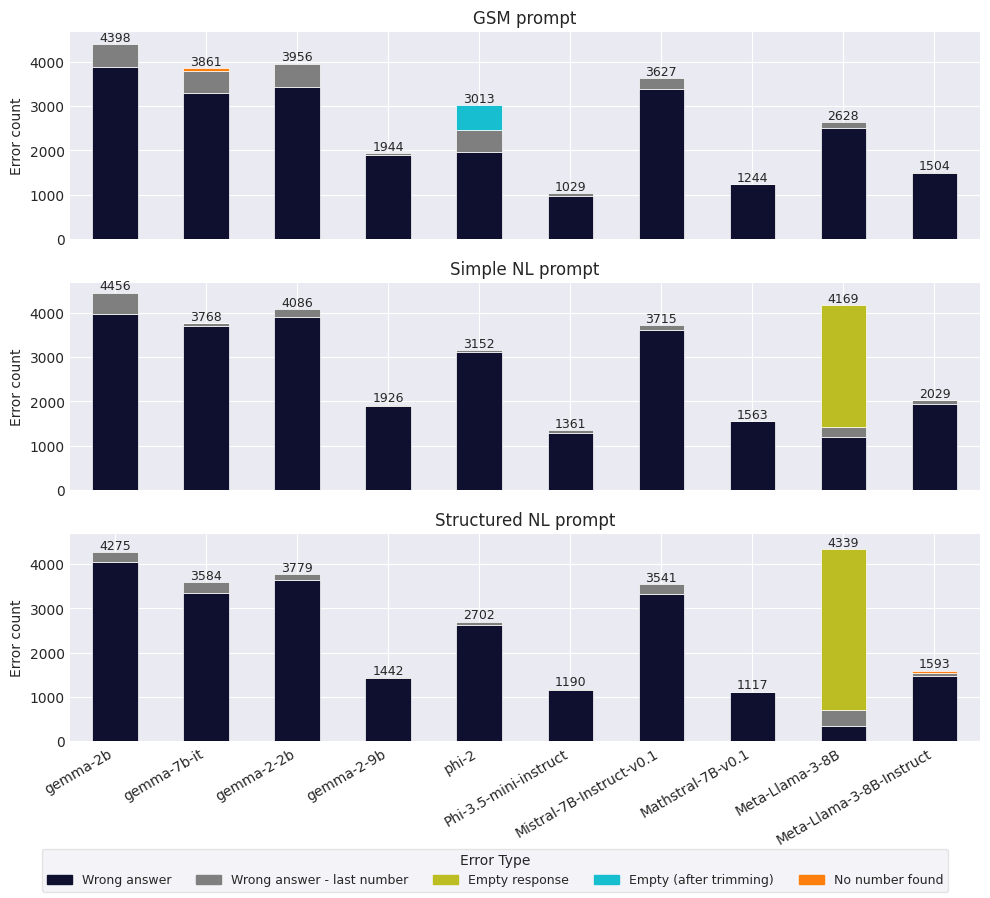

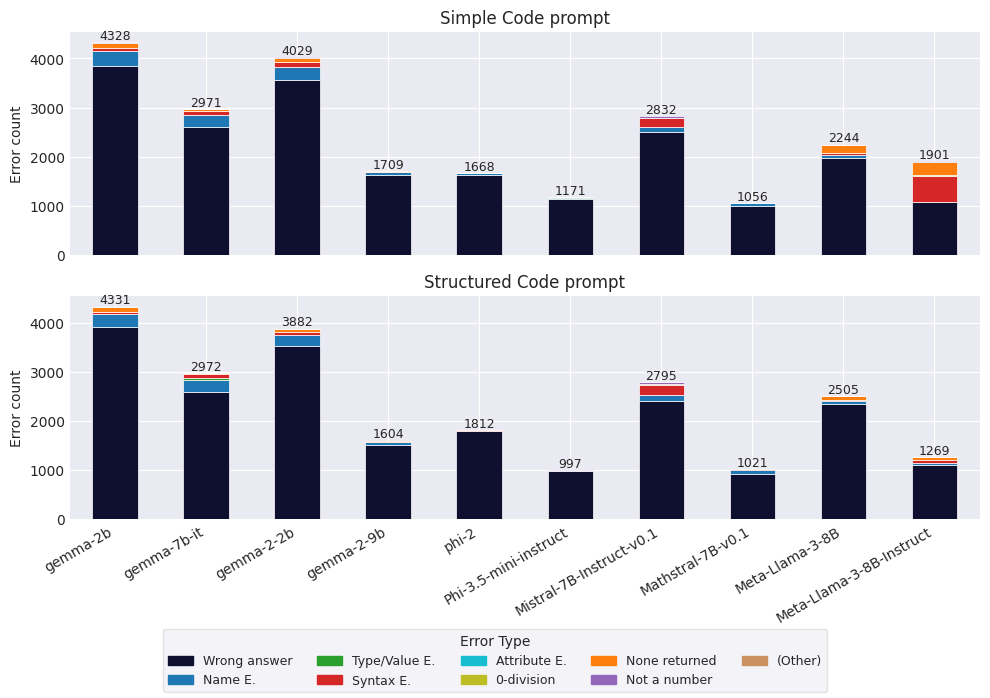

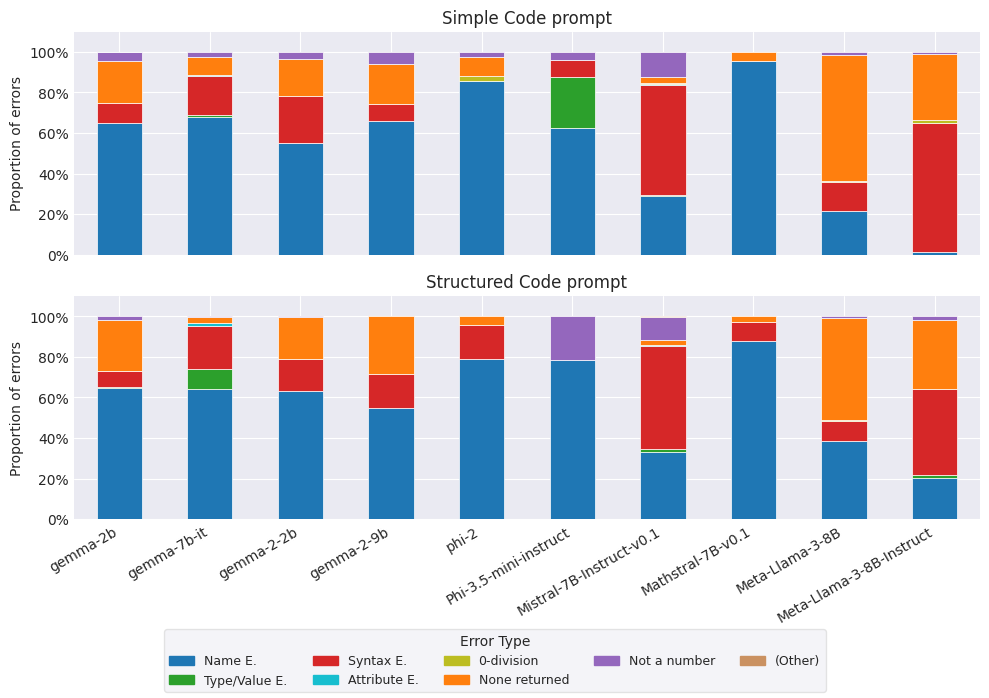

In [13]:
fig = plot_error_bars(nl_errors_df, percentages=False, bottom_margin=0.17, add_bar_labels=True, save_name='errors_nl')

fig = plot_error_bars(code_errors_df, percentages=False, bottom_margin=0.25, add_bar_labels=True, save_name='errors_code')
fig = plot_error_bars(code_errors_df[code_errors_df.error_type != 'NUMERICAL_ERROR'], percentages=True, bottom_margin=0.25, save_name='errors_code_perc')

In [14]:
other_errors = errors_df[errors_df.error_type == 'Other']
other_errors

,prompt,model,id,instance,error_type,question,numerical_result,predicted_numerical_result,full_response
98890,Simple Code,gemma-2b,49,39,Other,Hiroshi collects garbage from 5 different apar...,5775.0,NaN,\n apartments_before = 5\n apartments_pe...
124460,Structured Code,Mistral-7B-Instruct-v0.1,23,19,Other,Rania is knitting winter wear for her 4 grandc...,284.0,NaN,\n # given:\n grandchildren = 4 # numbe...


In [15]:
for i, row in other_errors.iterrows():
    print(row.full_response)
    print(AnswerExtractor.extract_answer_code(row.full_response))
    print("--------------------------------------\n\n\n")

Error when running extracted function: OverflowError: int too large to convert to float
Error when running extracted function: KeyError: 1



    apartments_before = 5
    apartments_per_complex = 350
    apartments_per_complex_total = apartments_before * apartments_per_complex
    apartments_per_complex_total_75 = apartments_per_complex_total * 0.75
    apartments_per_complex_total_sum = apartments_per_complex_total + apartments_per_complex_total_75
    apartments_per_complex_total_sum_3 = apartments_per_complex_total_sum * 3
    apartments_per_complex_total_sum_3_pay = apartments_per_complex_total_sum_3 * 0.5
    apartments_per_complex_total_sum_3_pay_total = apartments_per_complex_total_sum_3_pay * apartments_per_complex_total_sum_3
    apartments_per_complex_total_sum_3_pay_total_sum = apartments_per_complex_total_sum_3_pay_total + 10000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000

In [16]:
code_error_counts = code_errors_df[code_errors_df.error_type!='NUMERICAL_ERROR'].groupby('prompt').error_type.value_counts()
code_error_counts

prompt           error_type         
Simple Code      NAME_ERROR             1146
                 SYNTAX_ERROR            979
                 NONE_RETURNED           686
                 NOT_A_NUMBER            105
                 ZERO_DIVISION_ERROR      12
                 TYPE_VALUE_ERROR         11
                 ATTRIBUTE_ERROR           5
                 Other                     1
Structured Code  NAME_ERROR             1140
                 SYNTAX_ERROR            480
                 NONE_RETURNED           367
                 NOT_A_NUMBER             64
                 TYPE_VALUE_ERROR         46
                 ATTRIBUTE_ERROR           6
                 ZERO_DIVISION_ERROR       2
                 Other                     1
Name: count, dtype: int64

In [17]:
def cleaunp_table(table: pd.DataFrame):
    keys = list(ERROR_COLOURS.keys())
    if 'Other' not in table.columns:
        keys = keys[:-1]
    table = table.reindex(columns=keys).rename(columns=ERROR_NAMES)

    return table

In [18]:
for prompt in main_results.keys():
    if 'code' not in prompt.lower():
        continue
    df_prompt = code_errors_df[code_errors_df.prompt == prompt]

    counts = df_prompt.groupby(['error_type', 'model']).size().reset_index(name='error_count')
    counts_table = counts.pivot(index='model', columns='error_type', values='error_count')
    counts_table = cleaunp_table(counts_table)
    counts_table = counts_table.fillna(0)

    totals = counts_table.sum(axis=0)
    counts_table.loc['Total'] = totals
    counts_table = counts_table.apply(lambda v: v.astype(int).apply(str))
    counts_table.loc[r'Total [\%]'] = (totals / totals.sum() * 100).apply(lambda v: f"{v:.1f}")
    counts_table = counts_table.sort_index(
                key=lambda c: c.map({model: index for index, model in enumerate(original_model_order)})
            )


    print(pandas_to_latex(
        counts_table,
        label=f"tab:{prompt.lower().replace(' ', '-')}-error-types",
        caption=f"Error counts per error type for each model, {prompt} prompt.",
        position='H'
    ))


\begin{table}[H]
\caption{Error counts per error type for each model, Simple Code prompt.}
\label{tab:simple-code-error-types}
\begin{tabular}{lccccccccccccc}
\toprule
 & Wrong answer & Name E. & Type/Value E. & Syntax E. & Attribute E. & 0-division & None returned & Not a number & Wrong answer - last number & Empty response & Empty (after trimming) & No number found & (Other) \\
\midrule
gemma-2b & 3852 & 308 & 0 & 49 & 0 & 0 & 98 & 20 & 0 & 0 & 0 & 0 & 1 \\
gemma-7b-it & 2607 & 248 & 2 & 70 & 2 & 0 & 32 & 10 & 0 & 0 & 0 & 0 & 0 \\
gemma-2-2b & 3570 & 252 & 1 & 107 & 0 & 0 & 83 & 16 & 0 & 0 & 0 & 0 & 0 \\
gemma-2-9b & 1624 & 56 & 0 & 7 & 0 & 0 & 17 & 5 & 0 & 0 & 0 & 0 & 0 \\
phi-2 & 1626 & 36 & 0 & 0 & 0 & 1 & 4 & 1 & 0 & 0 & 0 & 0 & 0 \\
Phi-3.5-mini-instruct & 1147 & 15 & 6 & 2 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 & 0 \\
Mistral-7B-Instruct-v0.1 & 2505 & 94 & 2 & 177 & 3 & 1 & 9 & 41 & 0 & 0 & 0 & 0 & 0 \\
Mathstral-7B-v0.1 & 987 & 66 & 0 & 0 & 0 & 0 & 3 & 0 & 0 & 0 & 0 & 0 & 0 \\
Meta-L

In [19]:
for prompt in main_results.keys():
    if 'code' not in prompt.lower():
        continue
    df_prompt = code_errors_df[code_errors_df.prompt == prompt]

    counts = df_prompt.groupby(['error_type', 'model', 'id']).size().reset_index(name='error_count')

    top_indices = counts.groupby(['error_type', 'model'])['error_count'].idxmax()
    top_combinations = counts.loc[top_indices].copy()

    # create the formatted string: "TemplateID (Count)"
    top_combinations['cell_string'] = (
        top_combinations['id'].astype(str) +
        " (" +
        top_combinations['error_count'].astype(str) +
        ")"
    )

    # pivot the table
    top_id_table = top_combinations.pivot(
        index='model',
        columns='error_type',
        values='cell_string'
    )
    top_id_table = cleaunp_table(top_id_table)
    top_id_table = top_id_table.fillna('-')

    print(pandas_to_latex(
        top_id_table,
        label=f"tab:{prompt.lower().replace(' ', '-')}-errors-types-top-id",
        caption=f"Most frequent template IDs per error type for each model, {prompt} prompt. Total instances in parentheses.",
        position='H'
    ))

\begin{table}[H]
\caption{Most frequent template IDs per error type for each model, Simple Code prompt. Total instances in parentheses.}
\label{tab:simple-code-errors-types-top-id}
\begin{tabular}{lccccccccccccc}
\toprule
 & Wrong answer & Name E. & Type/Value E. & Syntax E. & Attribute E. & 0-division & None returned & Not a number & Wrong answer - last number & Empty response & Empty (after trimming) & No number found & (Other) \\
\midrule
Mathstral-7B-v0.1 & 45 (50) & 96 (29) & - & - & - & - & 80 (2) & - & - & - & - & - & - \\
Meta-Llama-3-8B & 0 (50) & 10 (10) & - & 2 (29) & - & 17 (1) & 88 (26) & 42 (1) & - & - & - & - & - \\
Meta-Llama-3-8B-Instruct & 0 (50) & 88 (6) & - & 78 (50) & - & 96 (8) & 42 (45) & 50 (7) & - & - & - & - & - \\
Mistral-7B-Instruct-v0.1 & 0 (50) & 21 (12) & 23 (1) & 5 (50) & 25 (2) & 82 (1) & 21 (2) & 57 (32) & - & - & - & - & - \\
Phi-3.5-mini-instruct & 55 (50) & 96 (3) & 21 (4) & 35 (1) & - & - & - & 80 (1) & - & - & - & - & - \\
gemma-2-2b & 9 (50) & 72